# Color Palettes

**geneview** ships a set of curated color resources tuned for genomics figures,
exposed through the `geneview.palette` module:

| Resource | Type | Description |
|----------|------|-------------|
| `generate_colors_palette` | function | Sample *n* colors from any matplotlib colormap, or pass an explicit color list through unchanged. |
| `circos` | dict (193 colors) | Named colors from the [Circos](http://circos.ca/) color scheme (e.g. `optblue`, `chr1`…`chr22`). |
| `xkcd_rgb` | dict (949 colors) | The XKCD color-survey names (e.g. `"acid green"`, `"denim blue"`). |

This tutorial shows how to generate, inspect, and apply these palettes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import geneview as gv
from geneview.palette import generate_colors_palette, circos, xkcd_rgb

print("geneview version:", gv.__version__)
print(f"circos:  {len(circos)} named colors")
print(f"xkcd_rgb: {len(xkcd_rgb)} named colors")

geneview version: 0.7.0
circos:  193 named colors
xkcd_rgb: 949 named colors


## A helper to display color swatches

The small helper below draws a horizontal strip of color swatches so we can
visually compare palettes throughout the tutorial.

In [2]:
def show_palette(colors, labels=None, title="", swatch_size=1.0):
    """Draw a row of color swatches."""
    n = len(colors)
    fig, ax = plt.subplots(figsize=(max(6, n * swatch_size), 1.4))
    for i, c in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=c, edgecolor="white", lw=1.5))
        if labels is not None:
            ax.text(i + 0.5, -0.15, labels[i], ha="right", va="top",
                    rotation=45, fontsize=8)
    ax.set_xlim(0, n)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 1. `generate_colors_palette` — sample from matplotlib colormaps

Pass any matplotlib colormap name and the number of colors you need. The
function returns evenly spaced RGBA tuples, ideal for coloring groups,
populations, or chromosomes.

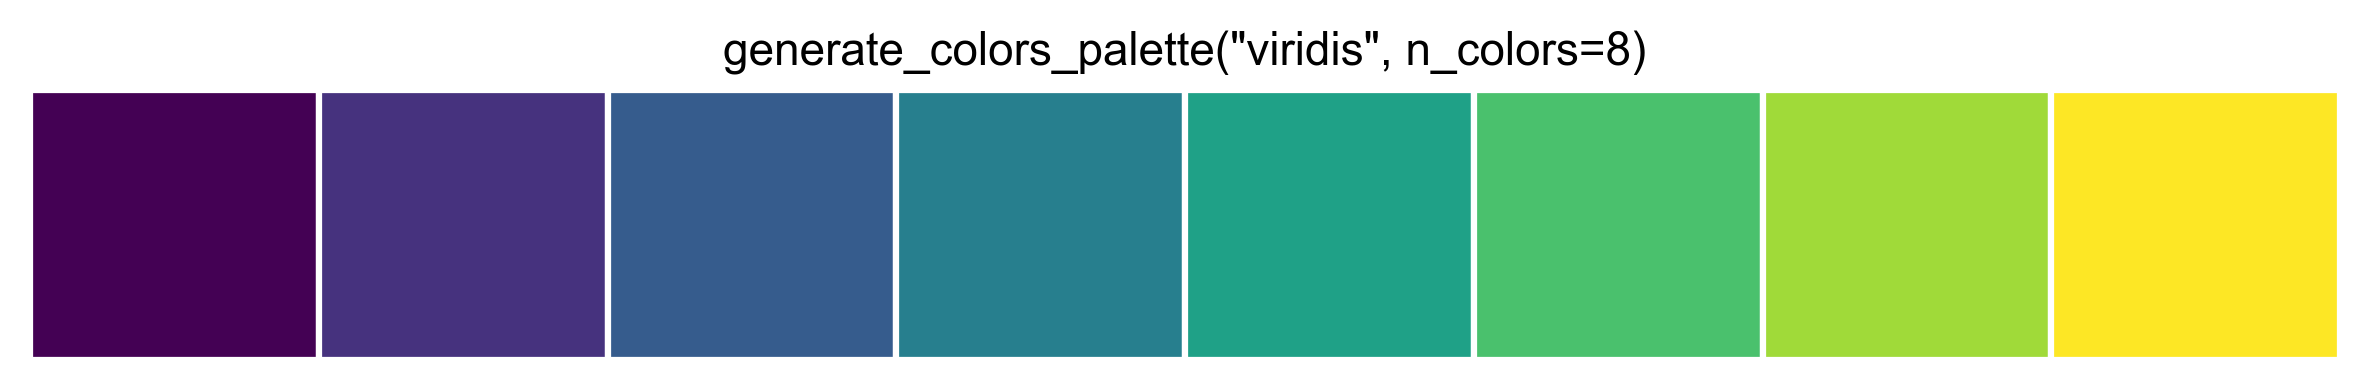

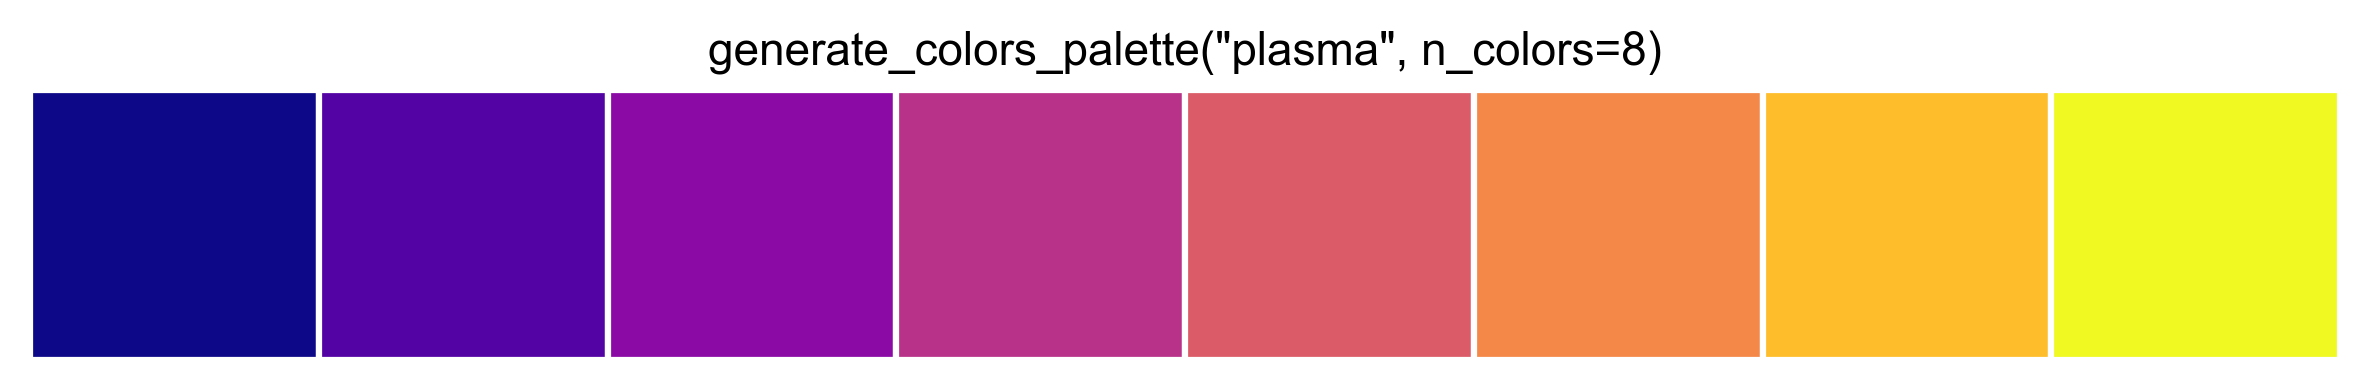

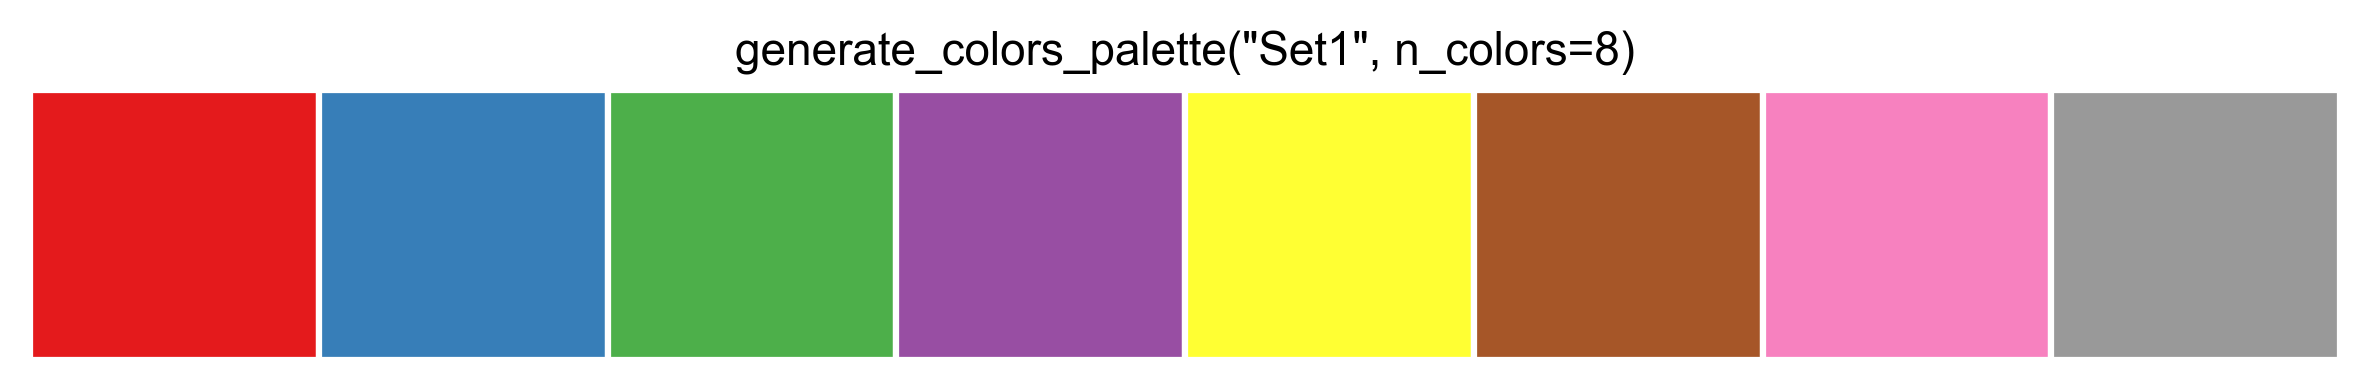

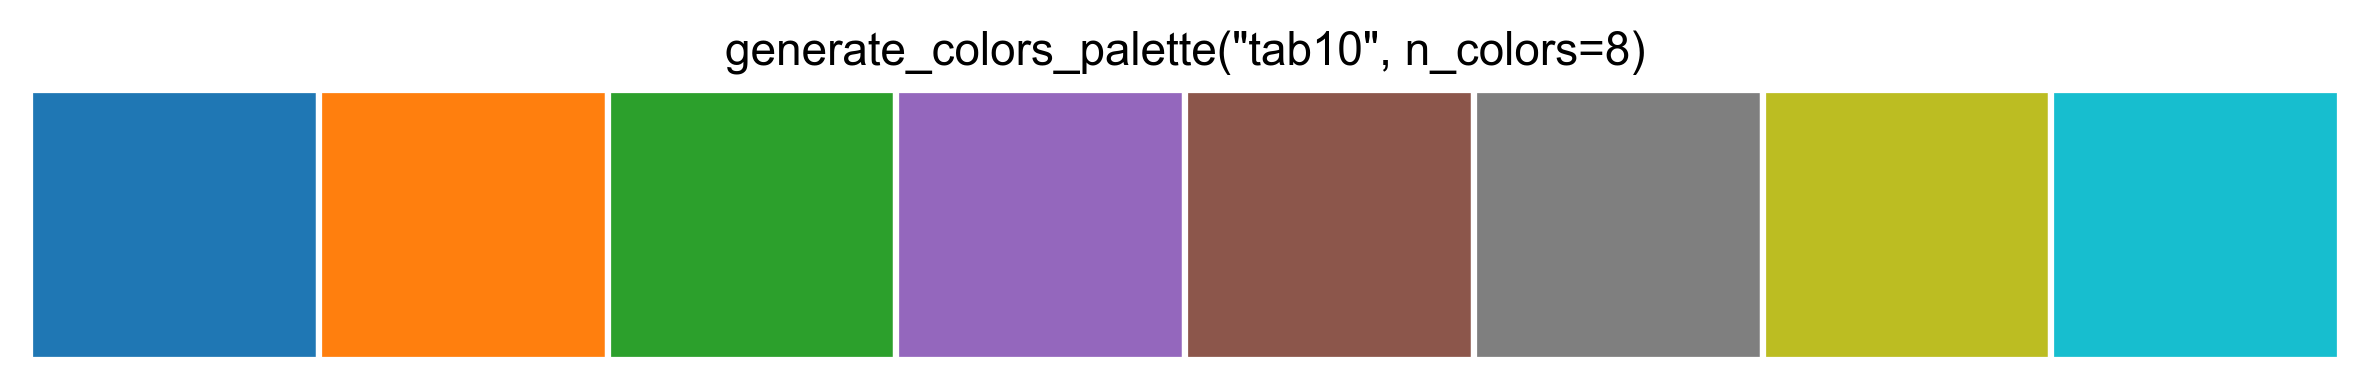

In [3]:
for cmap in ["viridis", "plasma", "Set1", "tab10"]:
    colors = generate_colors_palette(cmap=cmap, n_colors=8)
    show_palette(colors, title=f'generate_colors_palette("{cmap}", n_colors=8)')

### Control the number of colors and transparency

`n_colors` sets how many samples to draw across the colormap, and `alpha`
sets the opacity of every returned color.

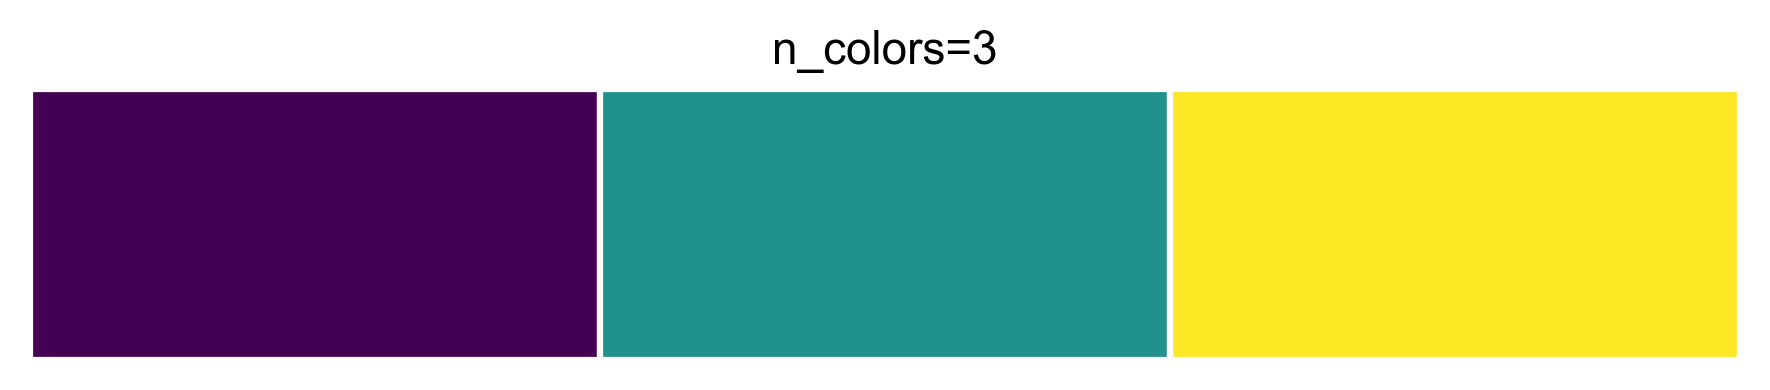

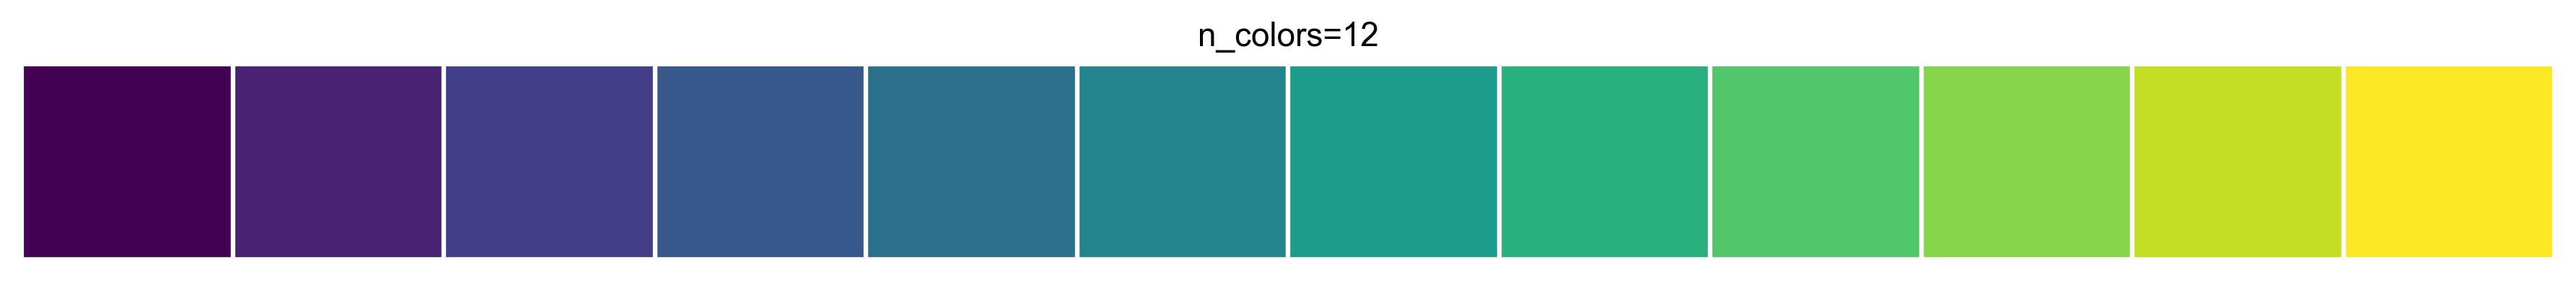

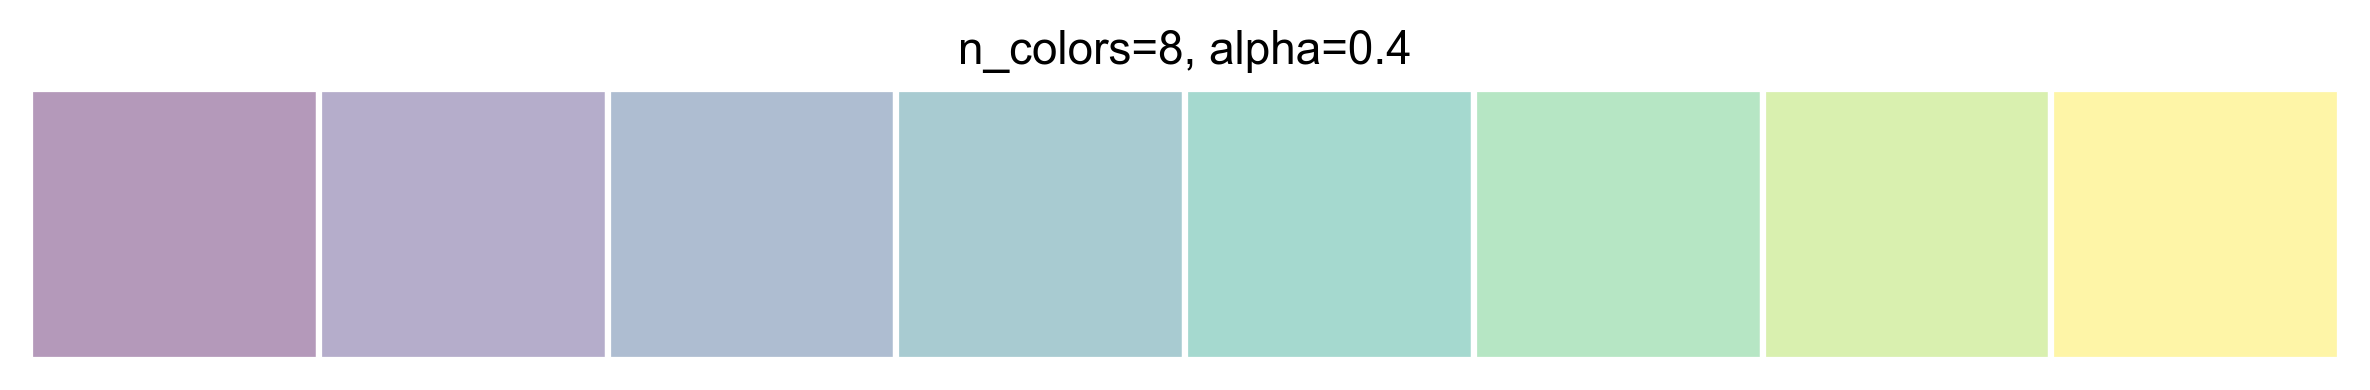

In [4]:
show_palette(generate_colors_palette("viridis", n_colors=3),  title="n_colors=3")
show_palette(generate_colors_palette("viridis", n_colors=12), title="n_colors=12")
show_palette(generate_colors_palette("viridis", n_colors=8, alpha=0.4),
             title="n_colors=8, alpha=0.4")

### Pass an explicit color list

If you already have exact hex colors, pass them as a list — they are returned
unchanged (as RGBA), so the same call site works for both colormap names and
custom colors.

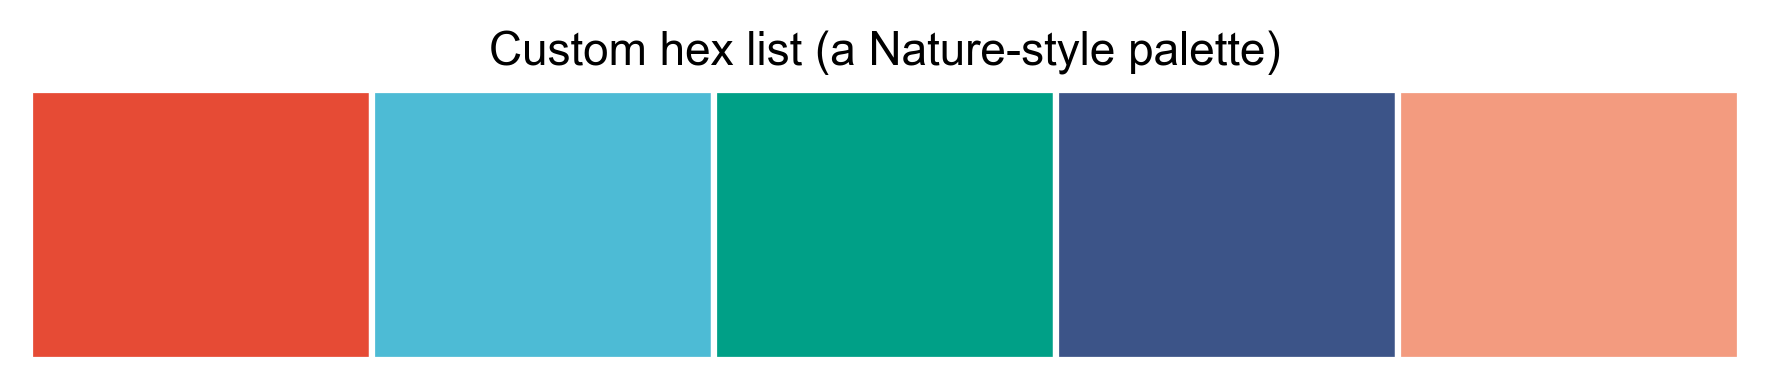

In [5]:
custom = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F"]
show_palette(generate_colors_palette(custom, n_colors=len(custom)),
             title="Custom hex list (a Nature-style palette)")

## 2. The Circos palette

The `circos` dictionary maps names to hex colors. It includes the familiar
per-chromosome colors (`chr1`…`chr22`, `chrX`, `chrY`) used by the Circos
software, plus a set of `opt*` accent colors.

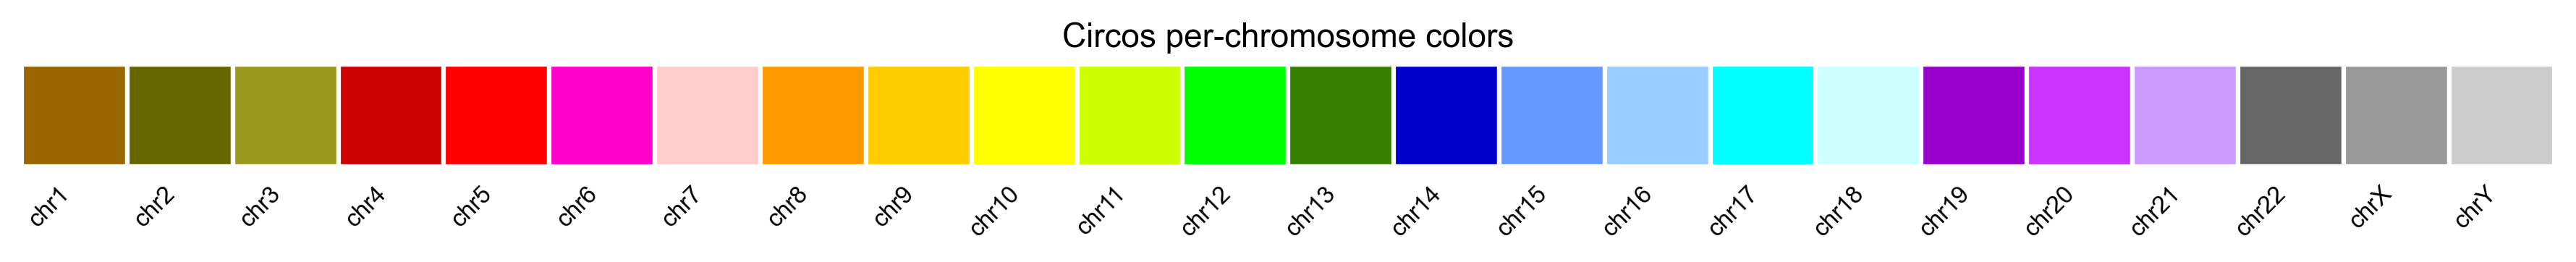

In [6]:
# Per-chromosome Circos colors
chrom_names = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
chrom_colors = [circos[c] for c in chrom_names if c in circos]
chrom_labels = [c for c in chrom_names if c in circos]
show_palette(chrom_colors, labels=chrom_labels,
             title="Circos per-chromosome colors", swatch_size=0.5)

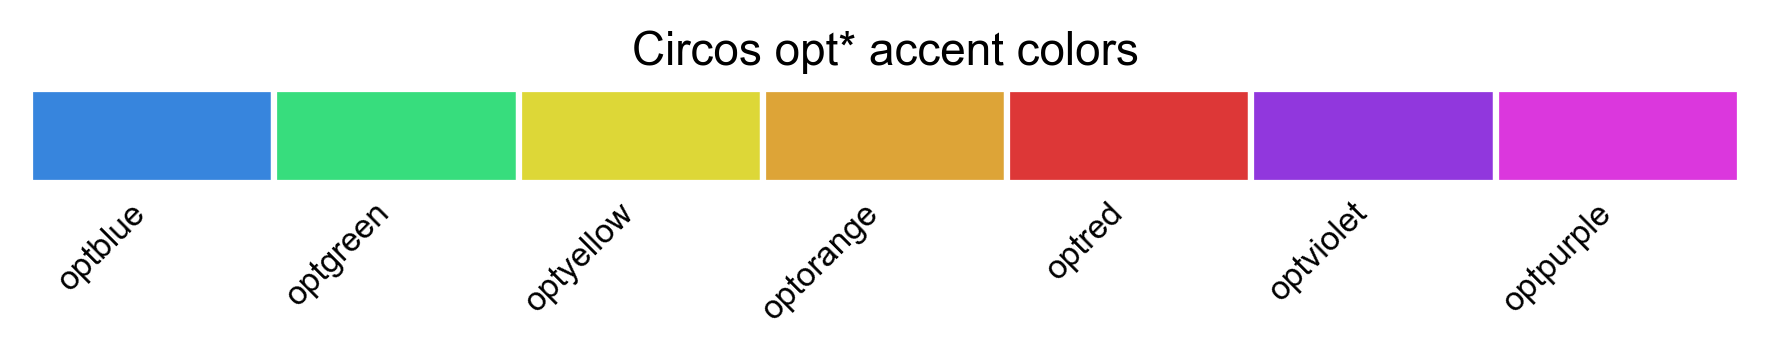

In [7]:
# The "opt" accent colors
opt_names = [k for k in circos if k.startswith("opt")]
show_palette([circos[k] for k in opt_names], labels=opt_names,
             title="Circos opt* accent colors", swatch_size=0.7)

## 3. The XKCD RGB palette

`xkcd_rgb` provides 949 human-named colors from the XKCD color survey. Look
colors up by their descriptive names.

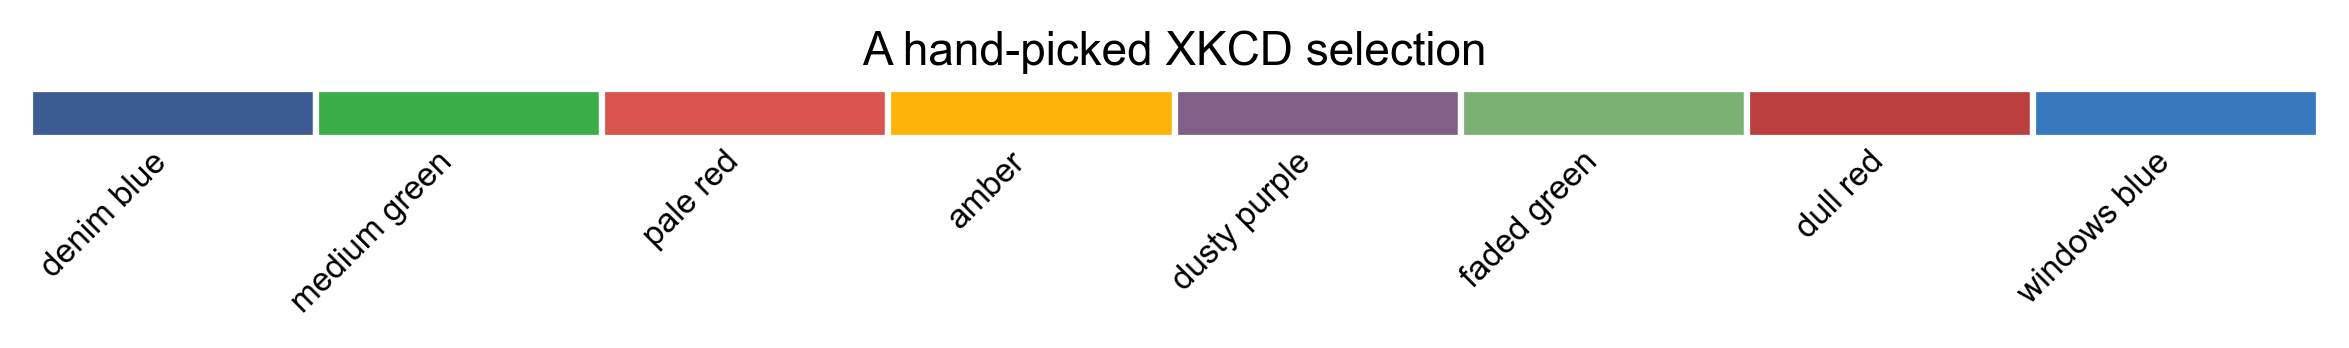

In [8]:
picks = ["denim blue", "medium green", "pale red", "amber",
         "dusty purple", "faded green", "dull red", "windows blue"]
show_palette([xkcd_rgb[p] for p in picks], labels=picks,
             title="A hand-picked XKCD selection", swatch_size=1.0)

## 4. Applying a palette to a plot

Any palette above can drive the colors of a real figure. Here we color a set
of grouped bars with a Circos-derived palette.

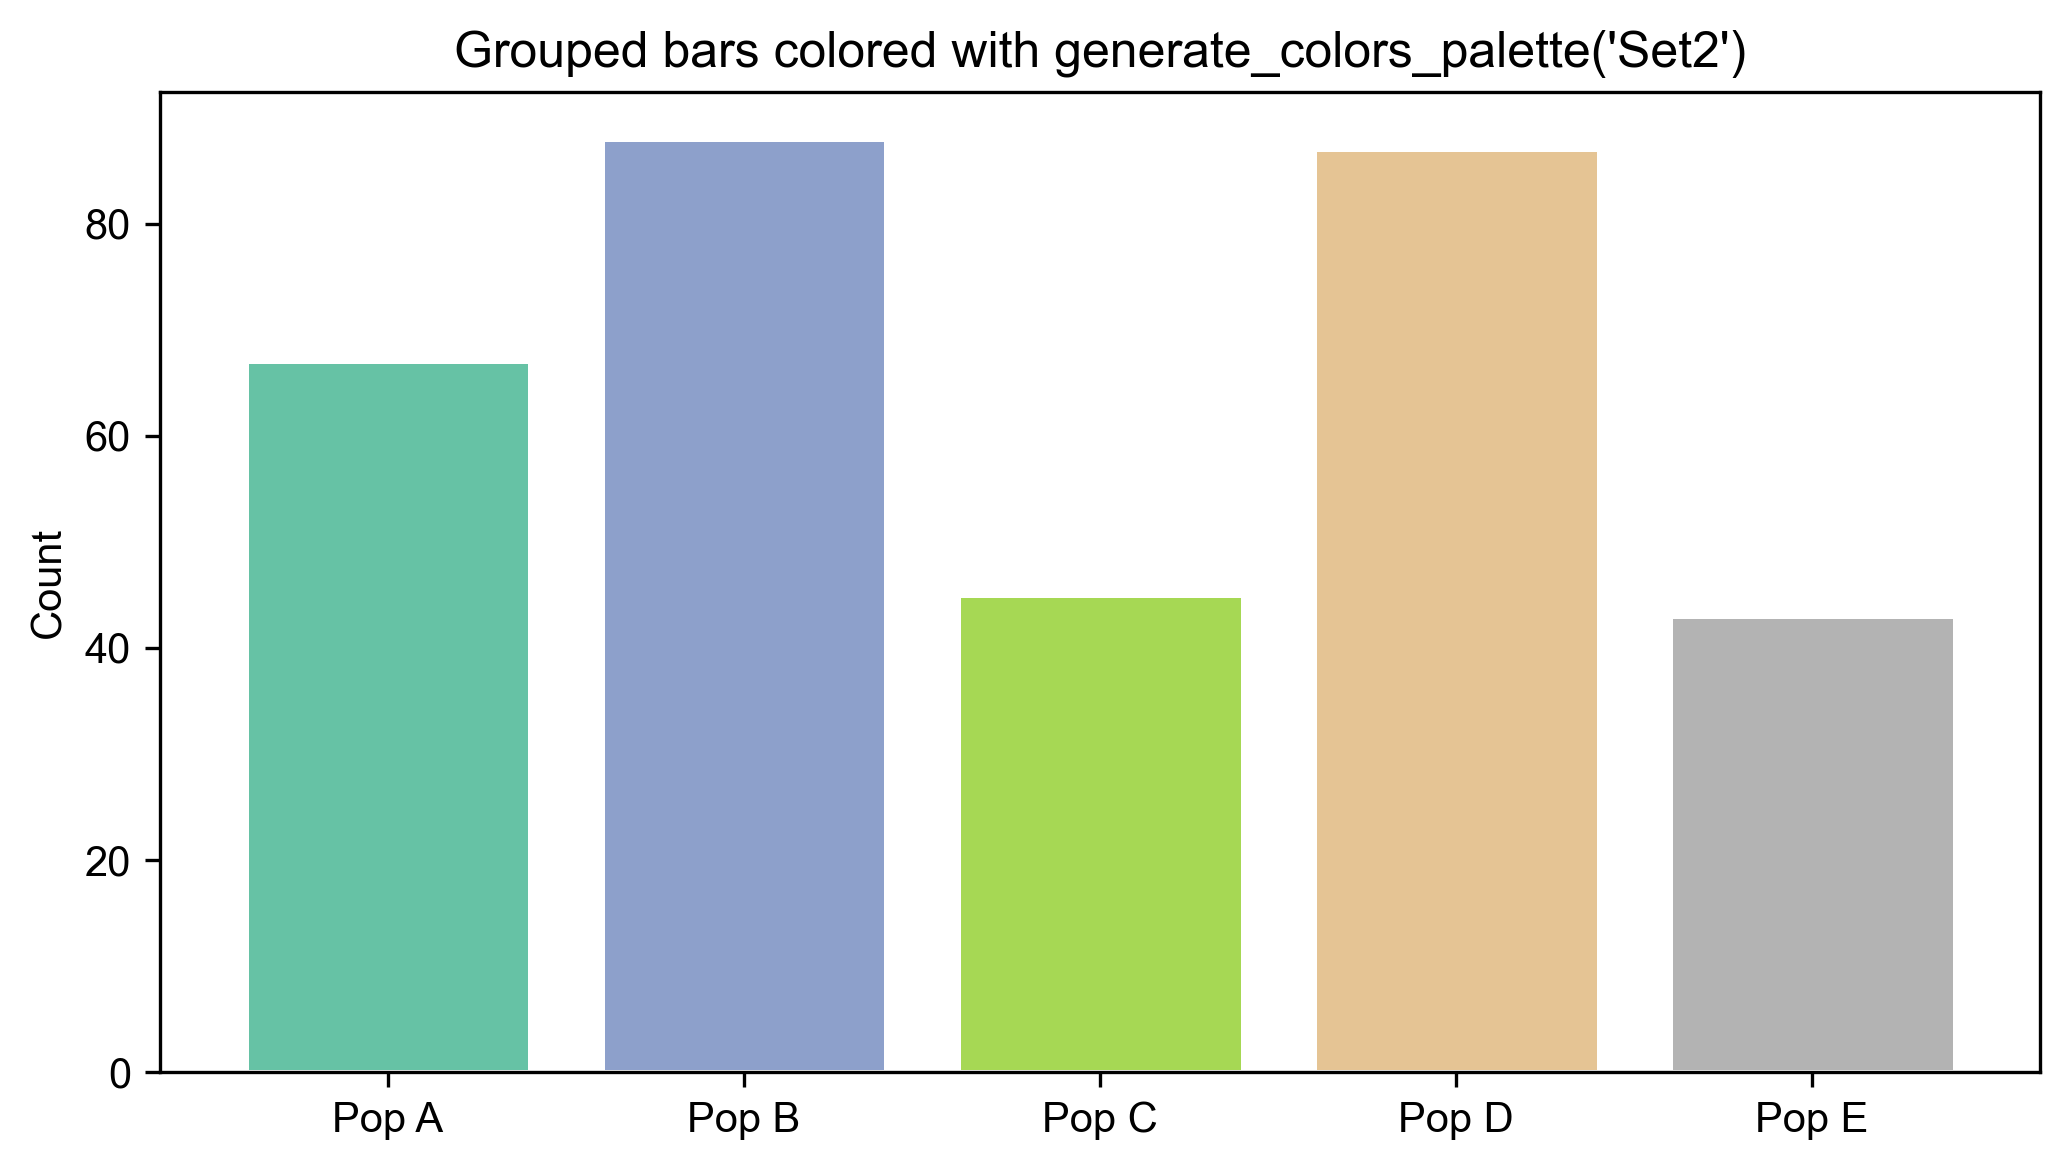

In [9]:
np.random.seed(7)
groups = ["Pop A", "Pop B", "Pop C", "Pop D", "Pop E"]
values = np.random.randint(20, 100, size=len(groups))
colors = generate_colors_palette("Set2", n_colors=len(groups))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(groups, values, color=colors, edgecolor="white", lw=1.2)
ax.set_ylabel("Count")
ax.set_title("Grouped bars colored with generate_colors_palette('Set2')")
plt.tight_layout()
plt.show()

## 5. Colorblind-safe journal palettes

The journal plot styles (`nature`, `science`, `cell`) each carry a
**colorblind-safe categorical palette**, exposed as
`get_style(name).tracks_categorical_palette`. geneview uses these automatically
to color multi-category content — e.g. multi-series `DataTrack`s or
forward/reverse alignment strands — so overlaid categories stay distinguishable,
including for readers with color-vision deficiency.

| Style | Palette | Origin |
|-------|---------|--------|
| `nature`  | Wong       | Wong, *Nature Methods* (2011) |
| `science` | Okabe-Ito  | Okabe & Ito colorblind-safe 8-color set |
| `cell`    | Cell       | Cell-press-tuned reordering of the above |

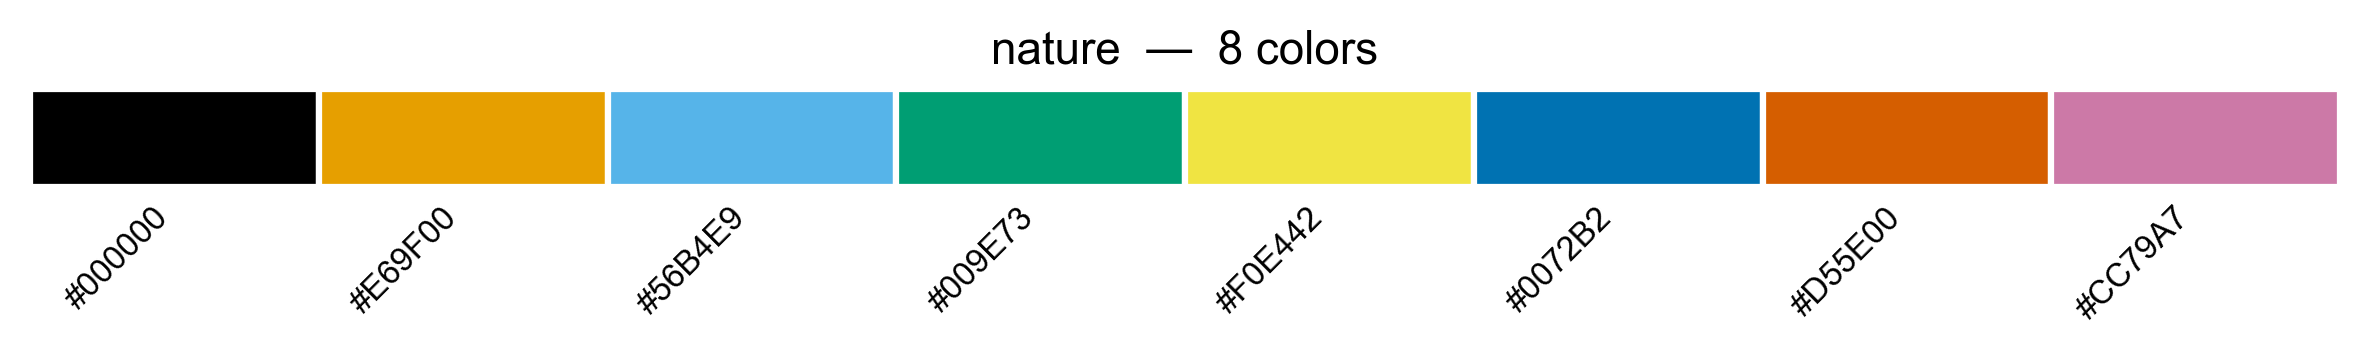

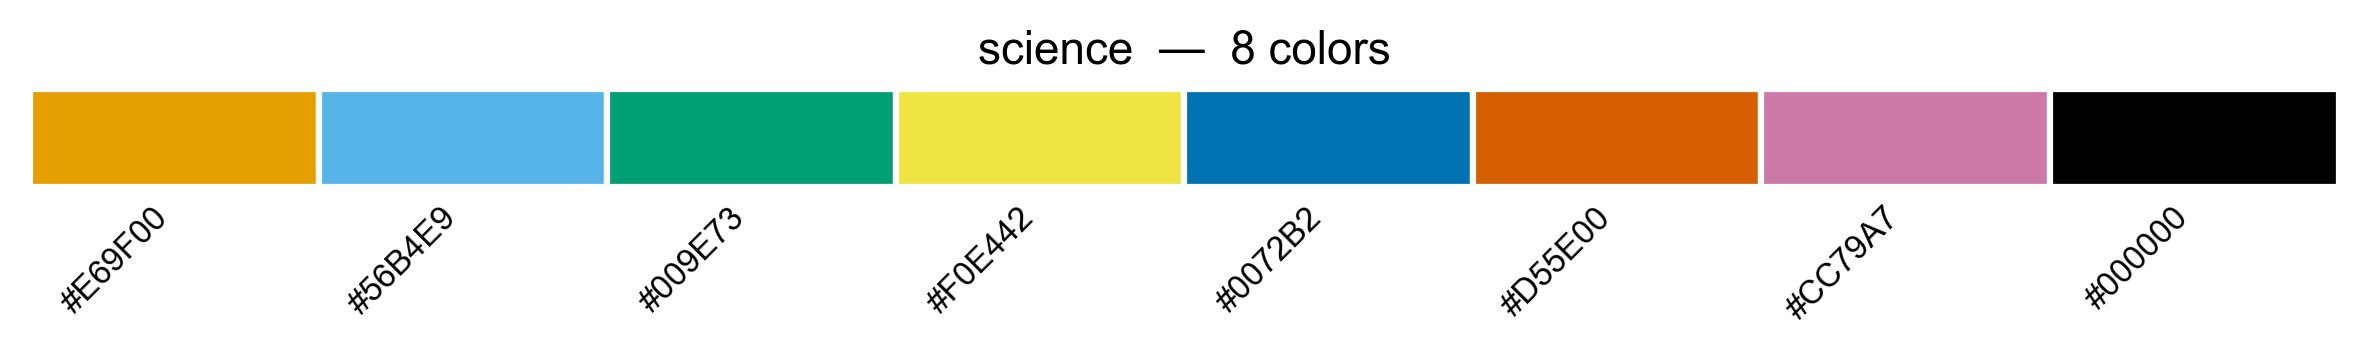

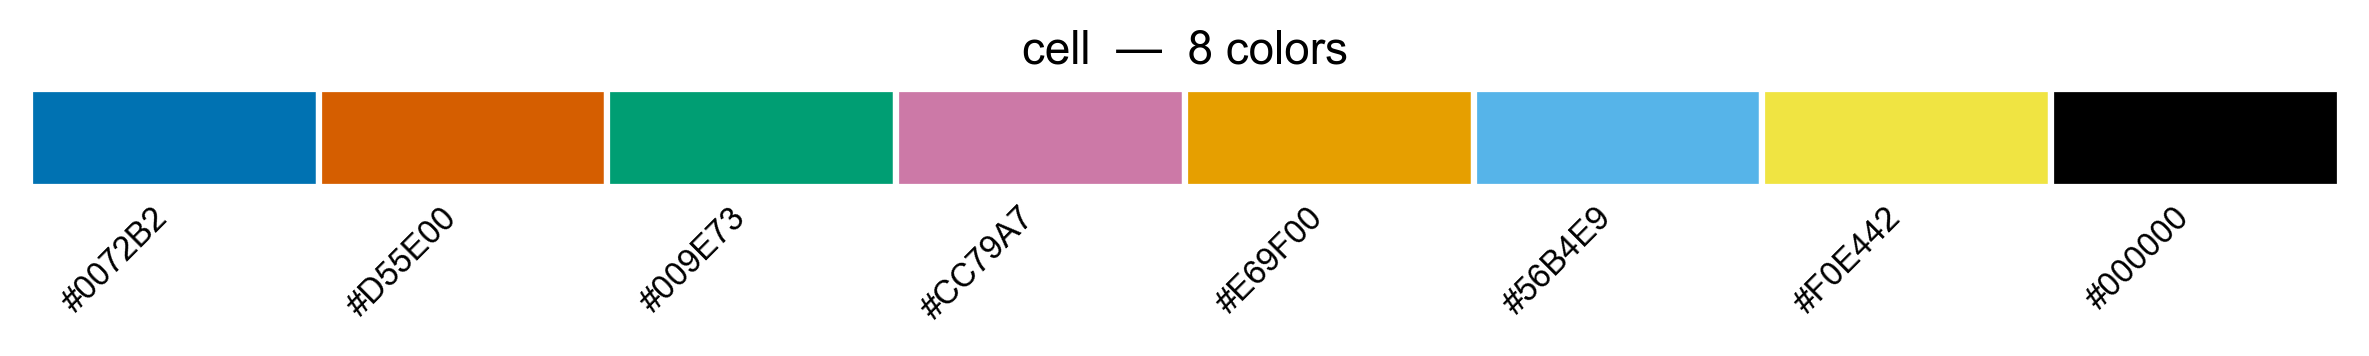

In [10]:
from geneview.plotstyle import get_style

for style_name in ["nature", "science", "cell"]:
    pal = get_style(style_name).tracks_categorical_palette
    show_palette(pal, labels=pal, title=f"{style_name}  —  {len(pal)} colors")

### Same figure, different palette

Multi-category data is where the palette matters most. Below we draw the *same*
four-series line plot and only swap the categorical palette. Under the default
`geneview` look there is no categorical palette, so every series shares one color
(hard to tell apart); each journal palette makes them distinct.

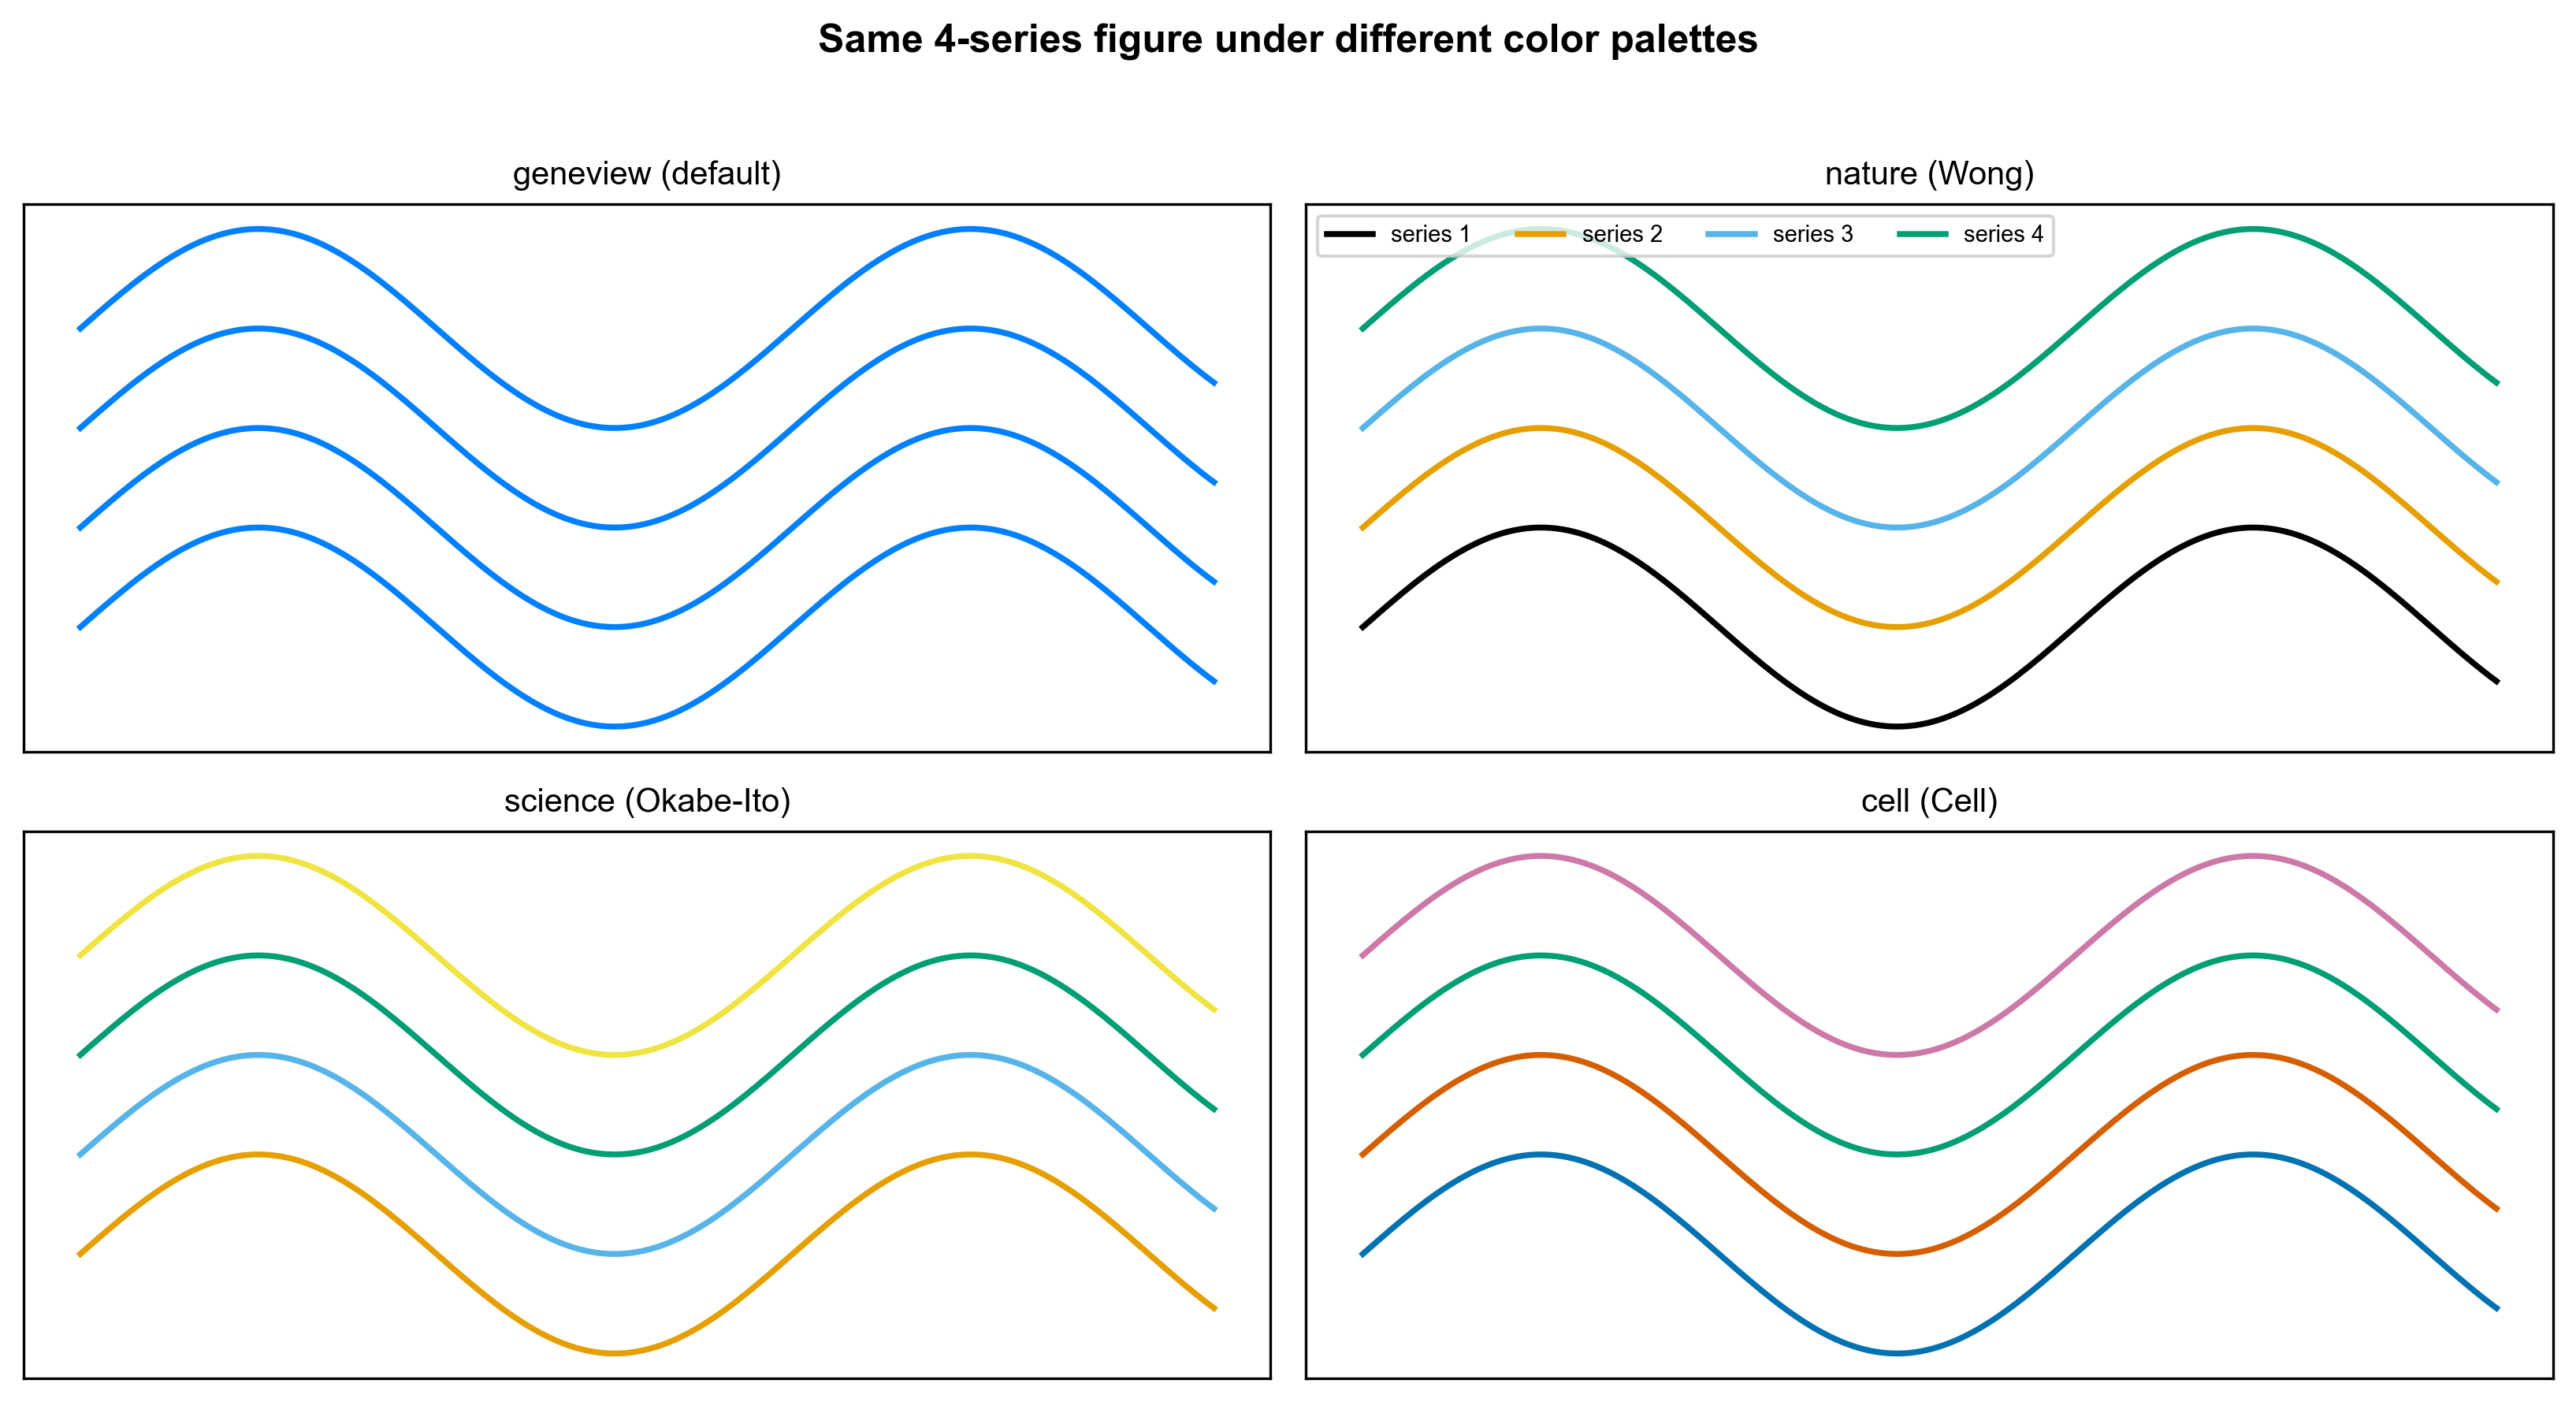

In [11]:
np.random.seed(2024)
x = np.linspace(0, 10, 200)
series = [np.sin(x) + i for i in range(4)]  # 4 overlaid series

palettes = {
    # geneview default carries no categorical palette -> falls back to one color
    "geneview (default)": get_style("geneview").tracks_categorical_palette or ["#0080FF"],
    "nature (Wong)": get_style("nature").tracks_categorical_palette,
    "science (Okabe-Ito)": get_style("science").tracks_categorical_palette,
    "cell (Cell)": get_style("cell").tracks_categorical_palette,
}

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, (label, pal) in zip(axes.flat, palettes.items()):
    for i, y in enumerate(series):
        ax.plot(x, y, color=pal[i % len(pal)], lw=1.8, label=f"series {i + 1}")
    ax.set_title(label, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
axes.flat[1].legend(loc="upper left", fontsize=7, ncol=4)
fig.suptitle("Same 4-series figure under different color palettes",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Summary

- `generate_colors_palette(cmap, n_colors, alpha)` samples colors from any
  matplotlib colormap, or passes an explicit color list through unchanged.
- `circos` offers 193 named colors including per-chromosome colors — handy for
  genome-wide plots such as Manhattan and Circos-style figures.
- `xkcd_rgb` offers 949 descriptively named colors for quick, readable choices.
- The journal styles (`nature`, `science`, `cell`) expose colorblind-safe
  categorical palettes via `get_style(name).tracks_categorical_palette`, applied
  automatically to multi-category track content.

These palettes integrate with every geneview plot that accepts a `color` or
`palette` argument, and with plain matplotlib.

**See also:** the [Plot Styles tutorial](./plotstyle.ipynb) for journal-compliant
color schemes (Nature, Science, Cell).